# HW6 - Self-Supervised and Contrastive Representation Learning (STL-10)

**Siva Surya Chandran** - sivasurya.chandran@sjsu.edu

ResNet-18 (no pretrained weights) is the backbone for every part:

| Part | What |
|:--|:--|
| A | Supervised, 10% of the labels (500 images), end to end |
| B | Rotation-prediction SSL on all 100,000 unlabeled images, then a linear probe on the same 500 labels |
| C | SimCLR-style contrastive learning on 20,000 unlabeled images, then a linear probe on the same 500 labels |
| D | Top-5 cosine nearest neighbours on the test set for all three encoders, same queries |

Run on an Apple-silicon Mac (MPS GPU). All augmentations are done on the GPU in batch.

## Step 0 - Personal parameters, seeds, environment

In [1]:
import os, time, json, random, hashlib, datetime
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchvision, matplotlib
import matplotlib.pyplot as plt

SID4 = 3215                     # see README: ID 019130215 -> 0215, leading zero replaced by 3
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")
print("(HW6 has no HP_ID mapping and no data slice; SEED, CLS_A and CLS_B are the ones used, CLS_A/CLS_B for the query images in Part D.)")

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__, "| torchvision", torchvision.__version__)
print("run started:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
os.makedirs("outputs", exist_ok=True); os.makedirs("checkpoints", exist_ok=True)
RESULTS = {"SID4": SID4, "SEED": SEED, "device": DEVICE}
T0 = time.time()
def stamp(msg): print(f"[{datetime.datetime.now().strftime('%H:%M:%S')} +{(time.time()-T0)/60:5.1f} min] {msg}", flush=True)

SID4=3215 SEED=3215 SLICE=215 HP_ID=5 CLS_A=5 CLS_B=2
(HW6 has no HP_ID mapping and no data slice; SEED, CLS_A and CLS_B are the ones used, CLS_A/CLS_B for the query images in Part D.)
device: mps | torch 2.14.1 | torchvision 0.29.1
run started: 2026-10-04 12:16:03


## Data

STL-10 (96x96 RGB, 10 classes): 5,000 labeled train, 8,000 test, 100,000 unlabeled. The 500-image labeled subset is
stratified (50 per class, 10% of train) and drawn with `SEED`. The same 500 images are used in Parts A, B and C.

In [2]:
def load(split):
    d = torchvision.datasets.STL10("data", split=split, download=True)
    x = torch.from_numpy(d.data)                       # uint8 N,3,96,96
    y = torch.from_numpy(d.labels).long() if hasattr(d, "labels") and d.labels is not None and len(d.labels) else None
    return x, y
xtr, ytr = load("train"); xte, yte = load("test"); xun, _ = load("unlabeled")
CLASSES = ["airplane","bird","car","cat","deer","dog","horse","monkey","ship","truck"]
print("train", tuple(xtr.shape), "test", tuple(xte.shape), "unlabeled", tuple(xun.shape))

# stratified 10% subset: 50 per class
rng = np.random.RandomState(SEED)
sub_idx = np.concatenate([rng.choice(np.where(ytr.numpy()==c)[0], 50, replace=False) for c in range(10)])
rng.shuffle(sub_idx)
x_lab, y_lab = xtr[sub_idx], ytr[sub_idx]
print("labeled subset:", tuple(x_lab.shape), "per-class counts:", torch.bincount(y_lab).tolist())
print("focus classes: CLS_A =", CLS_A, CLASSES[CLS_A], "| CLS_B =", CLS_B, CLASSES[CLS_B])

MEAN = torch.tensor([0.4467, 0.4398, 0.4066], device=DEVICE).view(1,3,1,1)
STD  = torch.tensor([0.2603, 0.2566, 0.2713], device=DEVICE).view(1,3,1,1)
def to_float(xb):                      # uint8 (cpu) -> float [0,1] on device
    return xb.to(DEVICE, non_blocking=True).float().div_(255)
def norm(x): return (x - MEAN) / STD

train (5000, 3, 96, 96) test (8000, 3, 96, 96) unlabeled (100000, 3, 96, 96)
labeled subset: (500, 3, 96, 96) per-class counts: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
focus classes: CLS_A = 5 dog | CLS_B = 2 car


## GPU augmentations

Implemented as batched tensor ops so training is not bottlenecked by CPU data loading. The four SimCLR augmentations
(the standard set; I did not have the course demo notebook, so these are the four it most plausibly uses):

1. **Random resized crop** (scale 0.2-1.0, aspect 3/4-4/3, resized back to 96x96)
2. **Random horizontal flip** (p=0.5)
3. **Colour jitter** (brightness/contrast/saturation 0.4, applied with p=0.8; hue omitted for speed)
4. **Random grayscale** (p=0.2)

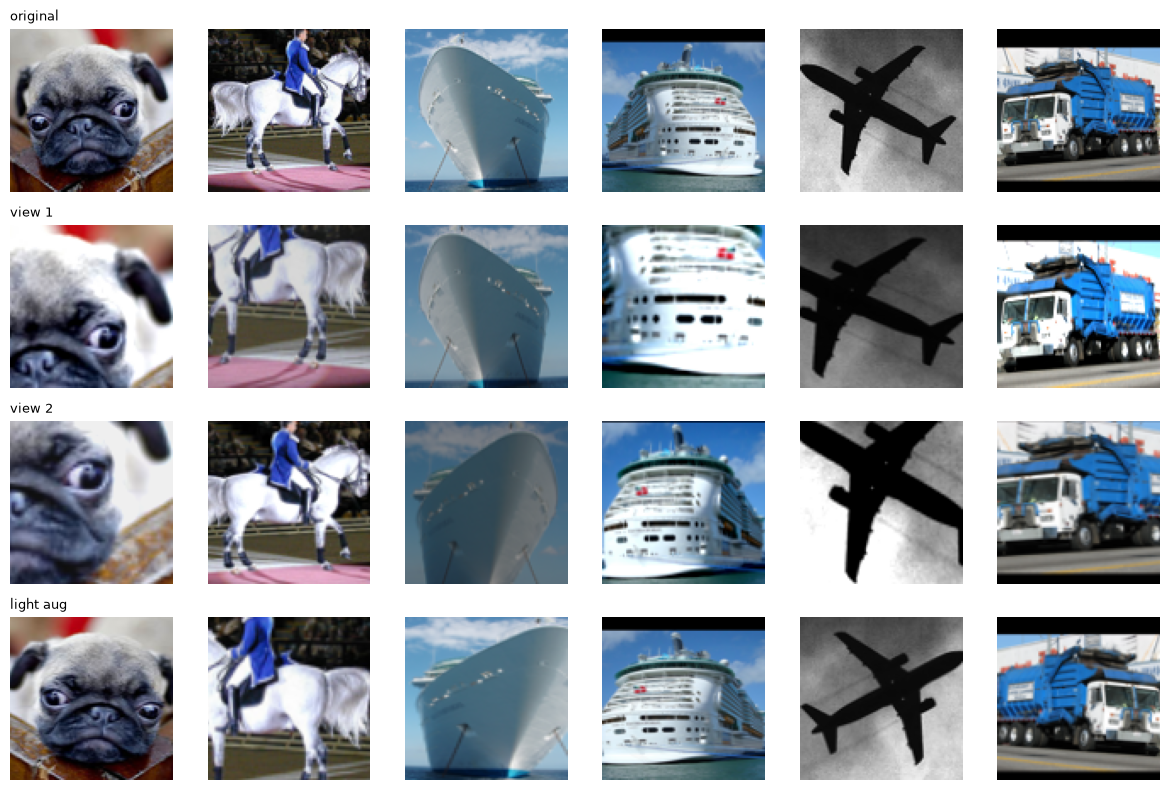

In [3]:
def rand_resized_crop_flip(x, scale=(0.2, 1.0), ratio=(3/4, 4/3), flip=True):
    """Per-sample random resized crop + horizontal flip, one affine grid_sample call."""
    B = x.shape[0]
    s = torch.empty(B, device=x.device).uniform_(*scale)
    r = torch.exp(torch.empty(B, device=x.device).uniform_(np.log(ratio[0]), np.log(ratio[1])))
    w = torch.sqrt(s * r).clamp(max=1.0); h = torch.sqrt(s / r).clamp(max=1.0)
    cx = (torch.rand(B, device=x.device) * 2 - 1) * (1 - w)
    cy = (torch.rand(B, device=x.device) * 2 - 1) * (1 - h)
    sign = torch.where(torch.rand(B, device=x.device) < 0.5, -1.0, 1.0) if flip else torch.ones(B, device=x.device)
    theta = torch.zeros(B, 2, 3, device=x.device)
    theta[:, 0, 0] = w * sign; theta[:, 0, 2] = cx; theta[:, 1, 1] = h; theta[:, 1, 2] = cy
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection", align_corners=False)

def gray(x): return (0.299*x[:,0:1] + 0.587*x[:,1:2] + 0.114*x[:,2:3])

def color_jitter(x, strength=0.4, p=0.8):
    B = x.shape[0]; d = x.device
    u = lambda: (1 + (torch.rand(B,1,1,1,device=d)*2-1)*strength)
    y = (x * u()).clamp(0,1)                                           # brightness
    m = gray(y).mean(dim=(1,2,3), keepdim=True); y = ((y-m)*u()+m).clamp(0,1)   # contrast
    g = gray(y); y = ((y-g)*u()+g).clamp(0,1)                          # saturation
    apply = (torch.rand(B,1,1,1,device=d) < p)
    return torch.where(apply, y, x)

def random_gray(x, p=0.2):
    apply = (torch.rand(x.shape[0],1,1,1,device=x.device) < p)
    return torch.where(apply, gray(x).expand_as(x), x)

def simclr_aug(x):    # the 4 augmentations
    return random_gray(color_jitter(rand_resized_crop_flip(x, scale=(0.2, 1.0))))

def light_aug(x):     # used for supervised training (Part A) and the rotation pretext (Part B): crop + flip only
    return rand_resized_crop_flip(x, scale=(0.5, 1.0))

# sanity picture of the augmentations
_x = to_float(x_lab[:6])
fig, ax = plt.subplots(4, 6, figsize=(12, 8))
for r, (name, im) in enumerate([("original", _x), ("view 1", simclr_aug(_x)), ("view 2", simclr_aug(_x)), ("light aug", light_aug(_x))]):
    for c in range(6):
        ax[r, c].imshow(im[c].permute(1,2,0).cpu().clamp(0,1)); ax[r, c].axis("off")
    ax[r, 0].set_title(name, loc="left", fontsize=9)
plt.tight_layout(); plt.savefig("outputs/augmentations.png", dpi=110); plt.show()

## Shared helpers - encoder, evaluation, linear probe

In [4]:
def make_encoder():
    """ResNet-18, random init, fc removed -> 512-d features."""
    m = torchvision.models.resnet18(weights=None)
    m.fc = nn.Identity()
    return m.to(DEVICE)

@torch.no_grad()
def embed(encoder, x_u8, bs=500):
    encoder.eval()
    out = [encoder(norm(to_float(x_u8[i:i+bs]))).cpu() for i in range(0, len(x_u8), bs)]
    return torch.cat(out)

@torch.no_grad()
def accuracy_from_logits_fn(fn, x_u8, y, bs=500):
    preds = torch.cat([fn(norm(to_float(x_u8[i:i+bs]))).argmax(1).cpu() for i in range(0, len(x_u8), bs)])
    return (preds == y).float().mean().item(), preds

def param_hash(m):
    h = hashlib.md5()
    for p in m.state_dict().values(): h.update(p.detach().cpu().numpy().tobytes())
    return h.hexdigest()

def per_class_acc(preds, y): return [ (preds[y==c]==c).float().mean().item() for c in range(10) ]

def linear_probe(encoder, name, epochs=20, lr=1e-2, bs=32):
    """Encoder frozen (eval mode, no grad, params never given to the optimizer); only nn.Linear(512,10) trains."""
    set_seed()
    for p in encoder.parameters(): p.requires_grad_(False)
    encoder.eval()
    h_before = param_hash(encoder)
    ftr = embed(encoder, x_lab); fte = embed(encoder, xte)
    mu, sd = ftr.mean(0, keepdim=True), ftr.std(0, keepdim=True) + 1e-6      # feature standardisation, fit on the 500 labeled images only
    ftr_n, fte_n = ((ftr-mu)/sd).to(DEVICE), ((fte-mu)/sd).to(DEVICE)
    clf = nn.Linear(512, 10).to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    ytr_d = y_lab.to(DEVICE); n = len(ftr_n); hist = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=DEVICE); tot = 0
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            loss = F.cross_entropy(clf(ftr_n[idx]), ytr_d[idx])
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()*len(idx)
        with torch.no_grad(): te_acc = (clf(fte_n).argmax(1).cpu() == yte).float().mean().item()
        hist.append({"epoch": ep+1, "train_loss": tot/n, "test_acc": te_acc})
    assert param_hash(encoder) == h_before, "encoder changed during linear probe!"
    preds = clf(fte_n).argmax(1).cpu()
    acc = (preds == yte).float().mean().item()
    stamp(f"{name}: linear probe {epochs} ep, final train loss {hist[-1]['train_loss']:.3f}, TEST ACC {acc*100:.2f}%  (encoder hash unchanged: {h_before[:8]})")
    return acc, preds, hist

def save_curve(hist, key, title, path):
    plt.figure(figsize=(5,3.2)); plt.plot([h["epoch"] for h in hist], [h[key] for h in hist], marker="o", ms=3)
    plt.xlabel("epoch"); plt.ylabel(key); plt.title(title); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(path, dpi=110); plt.show()

## Part A - Supervised with 10% labels (500 images)

ResNet-18 from scratch + a 10-way linear head, trained end to end for 15 epochs on the 500-image subset (AdamW, lr 1e-3,
cosine decay, batch 64, crop + flip augmentation). Test accuracy is measured on all 8,000 test images.

[12:16:19 +  0.3 min] Part A epoch  1/15  train loss 2.252  test acc 20.54%


[12:16:23 +  0.3 min] Part A epoch  2/15  train loss 1.993  test acc 23.23%


[12:16:26 +  0.4 min] Part A epoch  3/15  train loss 1.874  test acc 28.10%


[12:16:30 +  0.4 min] Part A epoch  4/15  train loss 1.714  test acc 14.29%


[12:16:34 +  0.5 min] Part A epoch  5/15  train loss 1.585  test acc 26.71%


...

[12:17:00 +  0.9 min] Part A epoch 12/15  train loss 0.681  test acc 44.57%


[12:17:04 +  1.0 min] Part A epoch 13/15  train loss 0.653  test acc 44.59%


[12:17:08 +  1.1 min] Part A epoch 14/15  train loss 0.589  test acc 43.87%


[12:17:12 +  1.1 min] Part A epoch 15/15  train loss 0.527  test acc 43.95%


[12:17:15 +  1.2 min] PART A  supervised 10% labels  TEST ACC = 43.95%


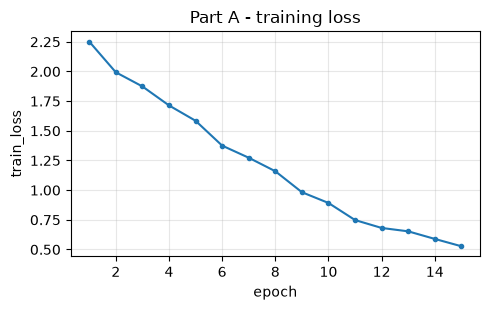

In [5]:
set_seed()
class Classifier(nn.Module):
    def __init__(self, enc): super().__init__(); self.enc = enc; self.head = nn.Linear(512, 10)
    def forward(self, x): return self.head(self.enc(x))

enc_sup = make_encoder(); model_a = Classifier(enc_sup).to(DEVICE)
EP_A, BS_A = 15, 64
opt = torch.optim.AdamW(model_a.parameters(), lr=1e-3, weight_decay=5e-4)
steps = EP_A * int(np.ceil(500/BS_A)); sched = torch.optim.lr_scheduler.OneCycleLR(opt, 1e-3, total_steps=steps, pct_start=0.15)
hist_a = []
for ep in range(EP_A):
    model_a.train(); perm = torch.randperm(500); tot = 0
    for i in range(0, 500, BS_A):
        idx = perm[i:i+BS_A]
        xb = norm(light_aug(to_float(x_lab[idx]))); yb = y_lab[idx].to(DEVICE)
        loss = F.cross_entropy(model_a(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); tot += loss.item()*len(idx)
    model_a.eval(); acc, _ = accuracy_from_logits_fn(model_a, xte, yte)
    hist_a.append({"epoch": ep+1, "train_loss": tot/500, "test_acc": acc})
    stamp(f"Part A epoch {ep+1:2d}/{EP_A}  train loss {tot/500:.3f}  test acc {acc*100:.2f}%")
acc_a, preds_a = accuracy_from_logits_fn(model_a, xte, yte)
RESULTS["A"] = {"test_acc": acc_a, "per_class": per_class_acc(preds_a, yte), "history": hist_a, "epochs": EP_A}
torch.save(enc_sup.state_dict(), "checkpoints/encoder_supervised.pt")
stamp(f"PART A  supervised 10% labels  TEST ACC = {acc_a*100:.2f}%")
save_curve(hist_a, "train_loss", "Part A - training loss", "outputs/partA_loss.png")

## Part B - Rotation self-supervised learning

Pretext task: every unlabeled image (all 100,000) is given a random rotation in {0, 90, 180, 270} each time it is drawn;
the network (ResNet-18 + 4-way rotation head) predicts which one. 15 epochs, AdamW lr 1e-3 with cosine decay, batch 256.
Then the rotation head is dropped, the encoder is frozen, and a linear classifier is trained on the same 500 labeled images
for 20 epochs.

[12:19:21 +  3.3 min] Part B pretext epoch  1/15  loss 1.0402  rotation acc 55.86%


[12:21:36 +  5.6 min] Part B pretext epoch  2/15  loss 0.8531  rotation acc 65.23%


[12:23:56 +  7.9 min] Part B pretext epoch  3/15  loss 0.7718  rotation acc 68.92%


[12:26:18 + 10.2 min] Part B pretext epoch  4/15  loss 0.7080  rotation acc 71.85%


[12:28:40 + 12.6 min] Part B pretext epoch  5/15  loss 0.6628  rotation acc 73.59%


...

[12:44:00 + 27.9 min] Part B pretext epoch 11/15  loss 0.4732  rotation acc 81.71%


[12:46:58 + 30.9 min] Part B pretext epoch 12/15  loss 0.4547  rotation acc 82.59%


[12:50:10 + 34.1 min] Part B pretext epoch 13/15  loss 0.4385  rotation acc 83.13%


[12:53:16 + 37.2 min] Part B pretext epoch 14/15  loss 0.4283  rotation acc 83.61%


[12:56:04 + 40.0 min] Part B pretext epoch 15/15  loss 0.4254  rotation acc 83.66%


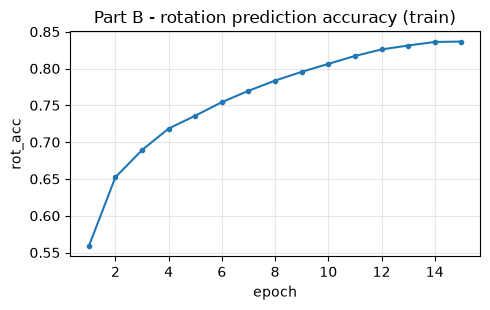

[12:56:09 + 40.1 min] Part B rotation accuracy on test images: 89.24%


[12:56:15 + 40.2 min] Part B rotation: linear probe 20 ep, final train loss 0.297, TEST ACC 47.85%  (encoder hash unchanged: a801cf62)


[12:56:15 + 40.2 min] PART B  rotation SSL + linear probe  TEST ACC = 47.85%


In [6]:
set_seed()
enc_rot = make_encoder(); rot_head = nn.Linear(512, 4).to(DEVICE)
EP_B, BS_B = 15, 256
params = list(enc_rot.parameters()) + list(rot_head.parameters())
opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
N_un = len(xun); steps_per_ep = N_un // BS_B
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EP_B*steps_per_ep)

def rotate_batch(x):
    k = torch.randint(0, 4, (x.shape[0],), device=x.device)
    out = x.clone()
    for r in range(1, 4):
        m = k == r
        if m.any(): out[m] = torch.rot90(x[m], r, dims=(2, 3))
    return out, k

hist_b = []
for ep in range(EP_B):
    enc_rot.train(); rot_head.train(); perm = torch.randperm(N_un); tot = cor = seen = 0
    for s in range(steps_per_ep):
        idx = perm[s*BS_B:(s+1)*BS_B]
        xb, kb = rotate_batch(light_aug(to_float(xun[idx])))
        logits = rot_head(enc_rot(norm(xb))); loss = F.cross_entropy(logits, kb)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        tot += loss.item()*len(idx); cor += (logits.argmax(1)==kb).sum().item(); seen += len(idx)
    hist_b.append({"epoch": ep+1, "train_loss": tot/seen, "rot_acc": cor/seen})
    stamp(f"Part B pretext epoch {ep+1:2d}/{EP_B}  loss {tot/seen:.4f}  rotation acc {cor/seen*100:.2f}%")
torch.save(enc_rot.state_dict(), "checkpoints/encoder_rotation.pt")
save_curve(hist_b, "rot_acc", "Part B - rotation prediction accuracy (train)", "outputs/partB_rot_acc.png")

# held-out rotation accuracy on the test images (sanity check that the pretext task was learned)
enc_rot.eval(); rot_head.eval(); set_seed(); c = n = 0
with torch.no_grad():
    for i in range(0, 8000, 500):
        xb, kb = rotate_batch(to_float(xte[i:i+500])); c += (rot_head(enc_rot(norm(xb))).argmax(1)==kb).sum().item(); n += len(kb)
RESULTS["B_pretext_test_rot_acc"] = c/n; stamp(f"Part B rotation accuracy on test images: {c/n*100:.2f}%")

# remove the rotation head, freeze the encoder, linear-probe on the 500 labels
del rot_head
acc_b, preds_b, hist_lin_b = linear_probe(enc_rot, "Part B rotation", epochs=20)
RESULTS["B"] = {"test_acc": acc_b, "per_class": per_class_acc(preds_b, yte), "pretext_history": hist_b, "linear_history": hist_lin_b, "pretext_epochs": EP_B, "linear_epochs": 20}
stamp(f"PART B  rotation SSL + linear probe  TEST ACC = {acc_b*100:.2f}%")

## Part C - SimCLR-style contrastive learning

20,000 unlabeled images (random subset, `SEED`). Each image gets two views from the 4 augmentations above. Encoder ->
projection head (512 -> 512 -> ReLU -> 128). NT-Xent loss with cosine similarity and **temperature 0.2**; the other
2(N-1) views in the batch are the negatives. Batch 256, 20 epochs, AdamW lr 1e-3 with cosine decay. Then the projection
head is dropped, the encoder frozen, and a linear classifier trained on the same 500 labeled images for 20 epochs.

[12:57:28 + 41.4 min] Part C pretext epoch  1/20  NT-Xent 5.1029  positive-pair top-1 8.2%


[12:58:41 + 42.6 min] Part C pretext epoch  2/20  NT-Xent 4.1900  positive-pair top-1 22.6%


[13:00:01 + 44.0 min] Part C pretext epoch  3/20  NT-Xent 3.8203  positive-pair top-1 33.2%


[13:01:18 + 45.2 min] Part C pretext epoch  4/20  NT-Xent 3.5523  positive-pair top-1 44.2%


[13:02:34 + 46.5 min] Part C pretext epoch  5/20  NT-Xent 3.3872  positive-pair top-1 51.8%


...

[13:15:36 + 59.5 min] Part C pretext epoch 16/20  NT-Xent 2.7344  positive-pair top-1 79.4%


[13:16:45 + 60.7 min] Part C pretext epoch 17/20  NT-Xent 2.7100  positive-pair top-1 80.1%


[13:17:56 + 61.9 min] Part C pretext epoch 18/20  NT-Xent 2.6858  positive-pair top-1 81.3%


[13:19:09 + 63.1 min] Part C pretext epoch 19/20  NT-Xent 2.6951  positive-pair top-1 80.7%


[13:20:20 + 64.3 min] Part C pretext epoch 20/20  NT-Xent 2.6759  positive-pair top-1 81.5%


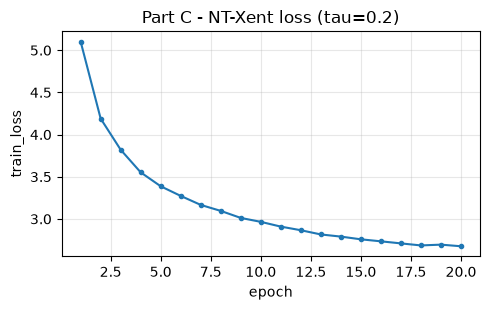

[13:20:26 + 64.4 min] Part C SimCLR: linear probe 20 ep, final train loss 0.471, TEST ACC 51.16%  (encoder hash unchanged: 853ffad0)


[13:20:26 + 64.4 min] PART C  SimCLR + linear probe  TEST ACC = 51.16%


In [7]:
set_seed()
simclr_idx = torch.from_numpy(np.random.RandomState(SEED).choice(len(xun), 20000, replace=False))
x_simclr = xun[simclr_idx]
enc_cl = make_encoder()
proj = nn.Sequential(nn.Linear(512, 512), nn.ReLU(inplace=True), nn.Linear(512, 128)).to(DEVICE)
TAU, EP_C, BS_C = 0.2, 20, 256
opt = torch.optim.AdamW(list(enc_cl.parameters()) + list(proj.parameters()), lr=1e-3, weight_decay=1e-5)
steps_per_ep = len(x_simclr) // BS_C
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EP_C*steps_per_ep)

def nt_xent(z1, z2, tau=TAU):
    z = F.normalize(torch.cat([z1, z2]), dim=1)            # cosine similarity = dot product of unit vectors
    sim = z @ z.t() / tau
    n = z1.shape[0]
    sim.fill_diagonal_(float("-inf"))                      # a view is not its own negative
    target = torch.cat([torch.arange(n, 2*n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, target), (sim.argmax(1) == target).float().mean().item()

hist_c = []
for ep in range(EP_C):
    enc_cl.train(); proj.train(); perm = torch.randperm(len(x_simclr)); tot = top1 = 0
    for s in range(steps_per_ep):
        xb = to_float(x_simclr[perm[s*BS_C:(s+1)*BS_C]])
        v1, v2 = norm(simclr_aug(xb)), norm(simclr_aug(xb))
        z = proj(enc_cl(torch.cat([v1, v2])))                # one forward pass over both views
        loss, t1 = nt_xent(z[:len(xb)], z[len(xb):])
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); tot += loss.item(); top1 += t1
    hist_c.append({"epoch": ep+1, "train_loss": tot/steps_per_ep, "pos_top1": top1/steps_per_ep})
    stamp(f"Part C pretext epoch {ep+1:2d}/{EP_C}  NT-Xent {tot/steps_per_ep:.4f}  positive-pair top-1 {top1/steps_per_ep*100:.1f}%")
torch.save(enc_cl.state_dict(), "checkpoints/encoder_simclr.pt")
save_curve(hist_c, "train_loss", "Part C - NT-Xent loss (tau=0.2)", "outputs/partC_loss.png")

del proj   # remove projection head, freeze encoder, linear probe
acc_c, preds_c, hist_lin_c = linear_probe(enc_cl, "Part C SimCLR", epochs=20)
RESULTS["C"] = {"test_acc": acc_c, "per_class": per_class_acc(preds_c, yte), "pretext_history": hist_c, "linear_history": hist_lin_c, "pretext_epochs": EP_C, "linear_epochs": 20, "tau": TAU}
stamp(f"PART C  SimCLR + linear probe  TEST ACC = {acc_c*100:.2f}%")

## Reference point - random (untrained) encoder + the same linear probe

Not required by the assignment. It shows how much of the linear-probe accuracy comes from the architecture alone, which is
needed to judge how much the self-supervised pretraining actually adds.

[13:20:32 + 64.5 min] Random-init encoder: linear probe 20 ep, final train loss 0.152, TEST ACC 28.59%  (encoder hash unchanged: 9a4415e8)


Model                                      test acc
A  Supervised, 500 labels, end-to-end       43.95%
B  Rotation SSL + linear                    47.85%
C  SimCLR + linear                          51.16%
(ref) random encoder + linear               28.59%


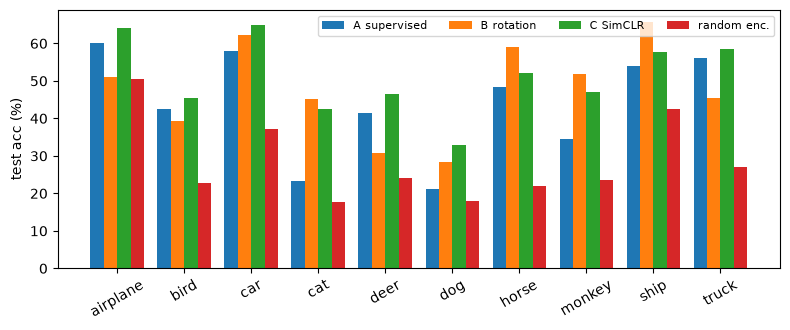

In [8]:
set_seed(); enc_rand = make_encoder()
acc_r, preds_r, _ = linear_probe(enc_rand, "Random-init encoder", epochs=20)
RESULTS["random_encoder"] = {"test_acc": acc_r, "per_class": per_class_acc(preds_r, yte)}

summary = [("A  Supervised, 500 labels, end-to-end", acc_a), ("B  Rotation SSL + linear", acc_b), ("C  SimCLR + linear", acc_c), ("(ref) random encoder + linear", acc_r)]
print(f"{'Model':42s} test acc"); [print(f"{n:42s} {a*100:6.2f}%") for n, a in summary]

fig, ax = plt.subplots(figsize=(8,3.4)); w = .2; xs = np.arange(10)
for i, (k, lab) in enumerate([("A","A supervised"),("B","B rotation"),("C","C SimCLR"),("random_encoder","random enc.")]):
    ax.bar(xs+(i-1.5)*w, np.array(RESULTS[k]["per_class"])*100, w, label=lab)
ax.set_xticks(xs); ax.set_xticklabels(CLASSES, rotation=30); ax.set_ylabel("test acc (%)"); ax.legend(ncol=4, fontsize=8); plt.tight_layout()
plt.savefig("outputs/per_class_accuracy.png", dpi=110); plt.show()

## Part D - Nearest-neighbour visualisation

512-d test-set embeddings from each encoder (the supervised encoder from Part A, the rotation encoder, the SimCLR encoder),
L2-normalised so a dot product is cosine similarity. For each query: top-5 neighbours among the other 7,999 test images
(the query itself is excluded). The queries are fixed once and shared by all three encoders: one image of `CLS_A` (dog), one of
`CLS_B` (car), and two more random classes. I also compute top-5 neighbour precision over **all** 8,000 test images, so the
conclusions don't rest on four hand-picked pictures.

[13:20:46 + 64.7 min] Supervised (A): precision@5 over all 8000 test queries = 39.66%, 1-NN accuracy = 42.40%


[13:20:46 + 64.7 min] Rotation SSL (B): precision@5 over all 8000 test queries = 40.97%, 1-NN accuracy = 44.74%


[13:20:46 + 64.7 min] SimCLR (C): precision@5 over all 8000 test queries = 44.96%, 1-NN accuracy = 49.44%


queries (test index, class): [(6224, 'dog'), (1842, 'car'), (3770, 'airplane'), (2209, 'deer')]
query 6224 (dog     ) Supervised (A)    -> ['monkey', 'deer', 'deer', 'cat', 'dog']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 6224 (dog     ) Rotation SSL (B)  -> ['horse', 'horse', 'dog', 'dog', 'horse']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 6224 (dog     ) SimCLR (C)        -> ['horse', 'horse', 'dog', 'deer', 'horse']  cos=[0.93, 0.93, 0.92, 0.92, 0.9]


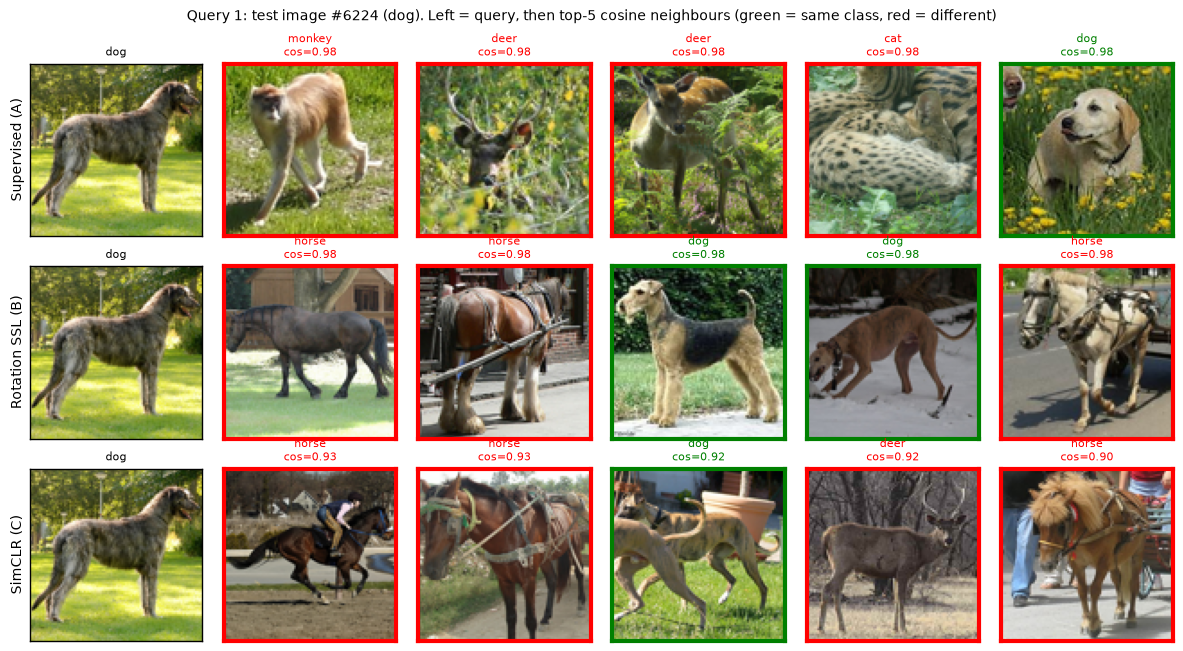

query 1842 (car     ) Supervised (A)    -> ['car', 'car', 'car', 'car', 'car']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 1842 (car     ) Rotation SSL (B)  -> ['car', 'truck', 'truck', 'truck', 'car']  cos=[0.99, 0.98, 0.98, 0.98, 0.98]
query 1842 (car     ) SimCLR (C)        -> ['car', 'car', 'car', 'car', 'car']  cos=[0.94, 0.94, 0.93, 0.93, 0.93]


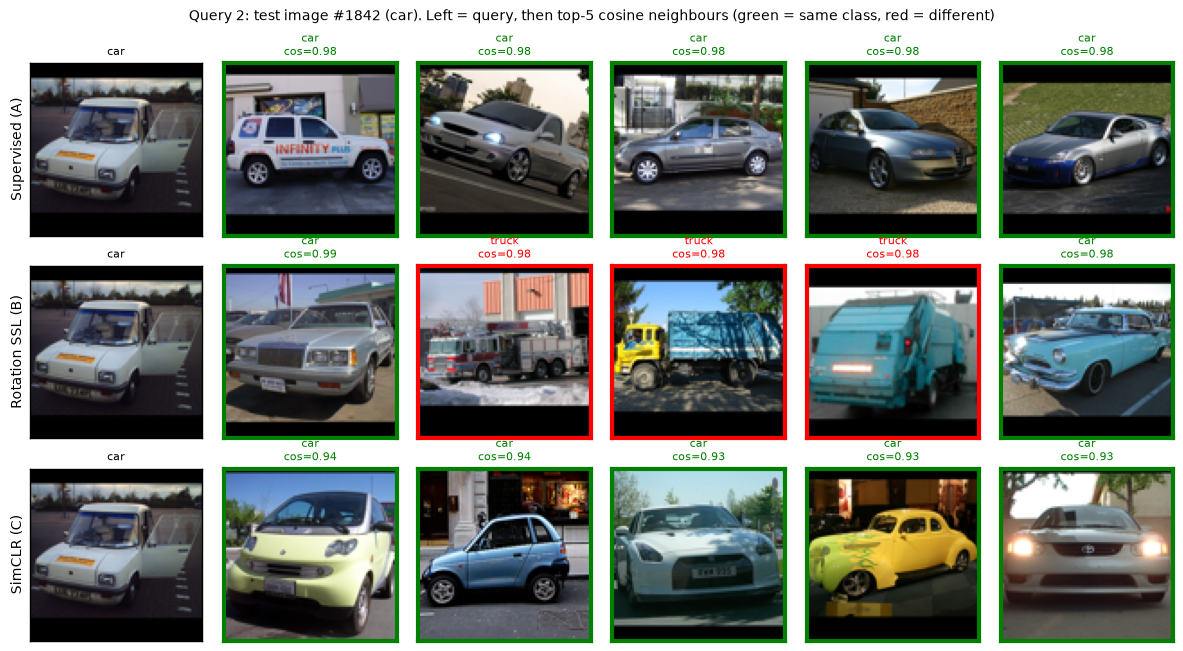

query 3770 (airplane) Supervised (A)    -> ['ship', 'airplane', 'airplane', 'airplane', 'ship']  cos=[0.95, 0.95, 0.95, 0.94, 0.94]
query 3770 (airplane) Rotation SSL (B)  -> ['airplane', 'airplane', 'ship', 'airplane', 'airplane']  cos=[0.98, 0.97, 0.97, 0.97, 0.97]
query 3770 (airplane) SimCLR (C)        -> ['airplane', 'airplane', 'truck', 'airplane', 'ship']  cos=[0.92, 0.91, 0.9, 0.89, 0.89]


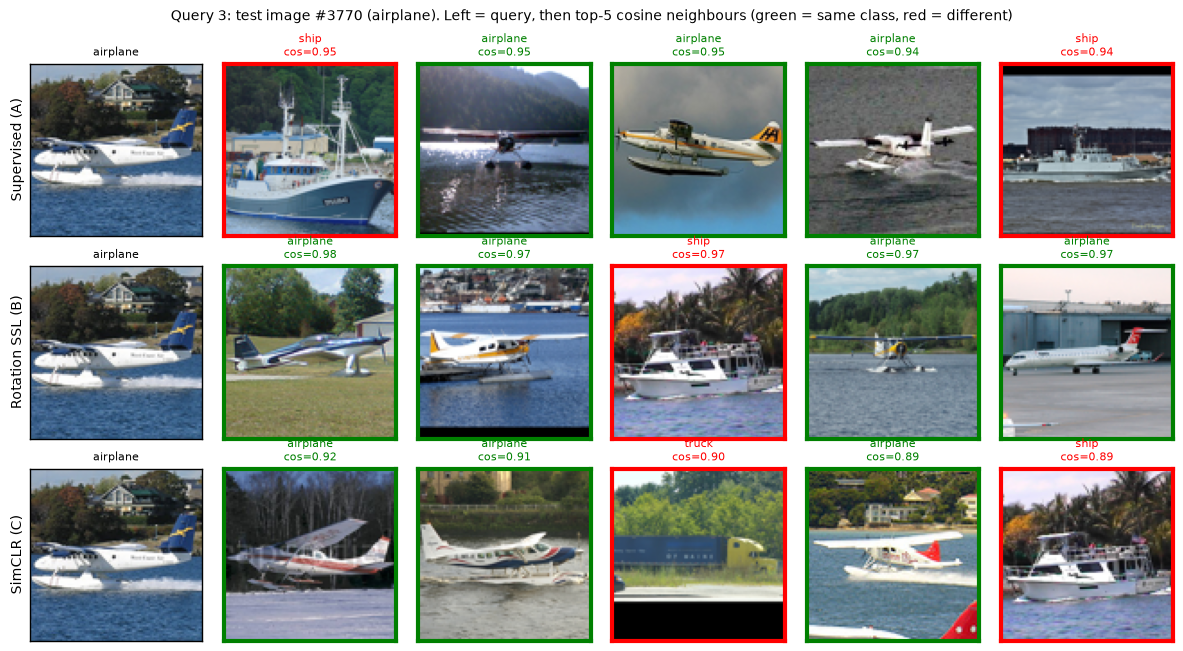

query 2209 (deer    ) Supervised (A)    -> ['deer', 'deer', 'monkey', 'deer', 'deer']  cos=[0.97, 0.96, 0.96, 0.96, 0.96]
query 2209 (deer    ) Rotation SSL (B)  -> ['deer', 'deer', 'horse', 'car', 'horse']  cos=[0.99, 0.99, 0.99, 0.99, 0.99]
query 2209 (deer    ) SimCLR (C)        -> ['deer', 'deer', 'deer', 'deer', 'dog']  cos=[0.95, 0.93, 0.92, 0.92, 0.9]


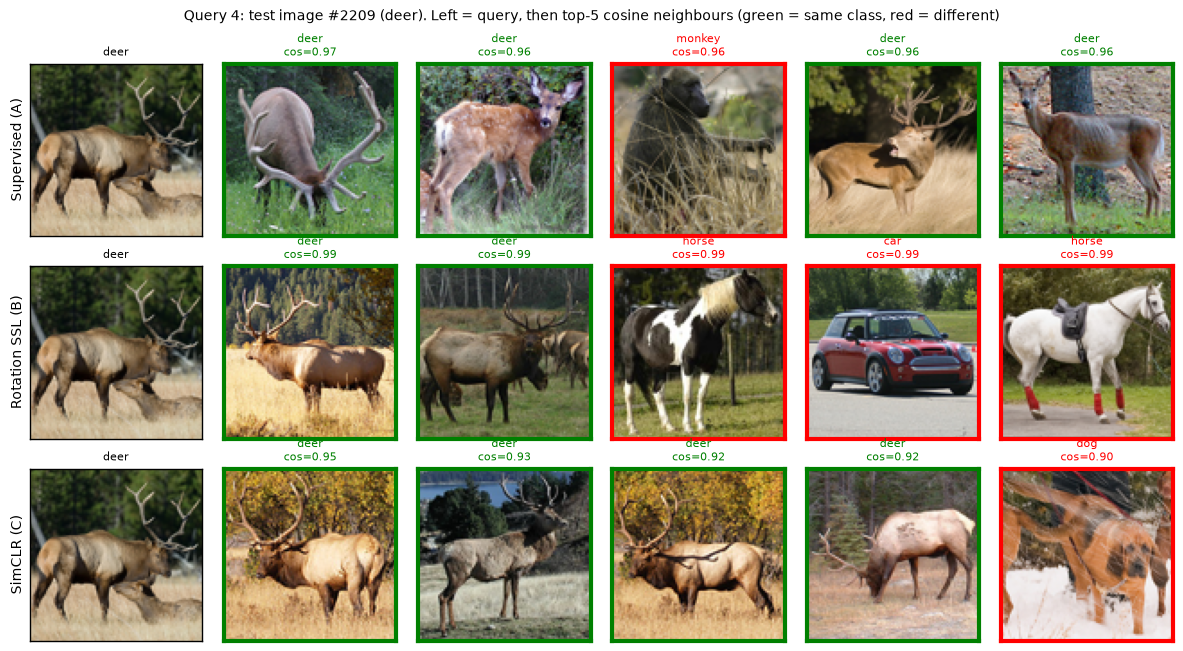

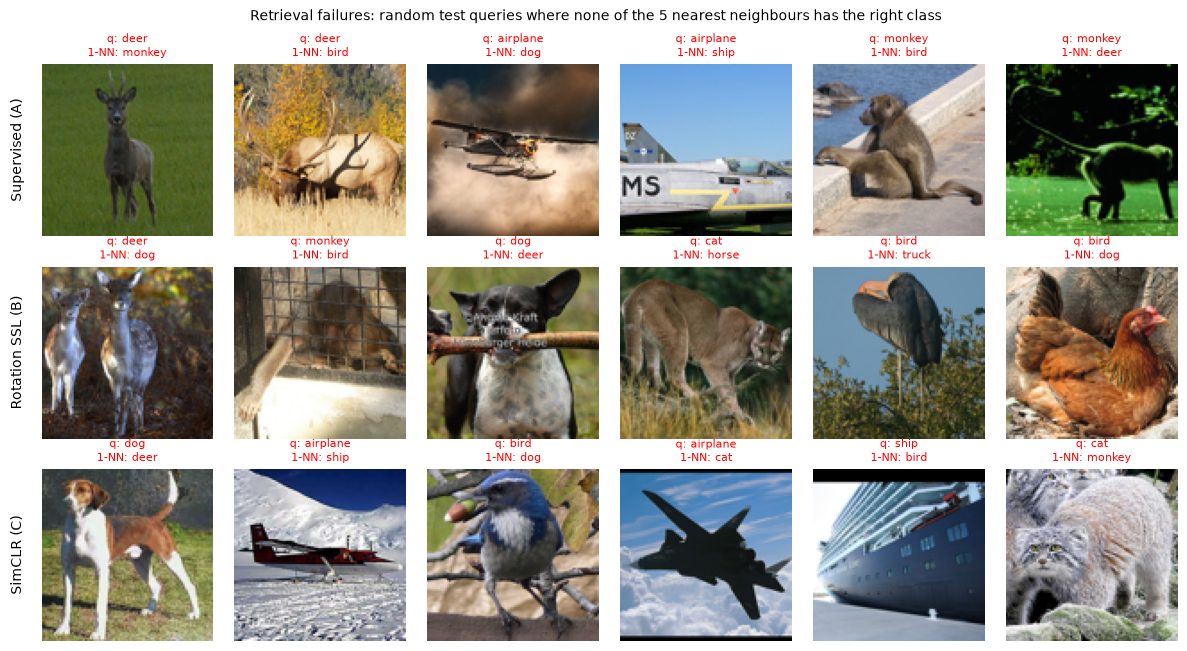

{'Supervised (A)': 1825, 'Rotation SSL (B)': 1591, 'SimCLR (C)': 1516} queries (of 8000) with 0/5 correct neighbours


In [9]:
emb = {"Supervised (A)": embed(enc_sup, xte), "Rotation SSL (B)": embed(enc_rot, xte), "SimCLR (C)": embed(enc_cl, xte)}
emb = {k: F.normalize(v, dim=1) for k, v in emb.items()}

def topk(e, q, k=5):
    sims = e @ e[q]; sims[q] = -2          # exclude the query itself
    v, i = sims.topk(k); return i.tolist(), v.tolist()

# full-test-set neighbour precision (top-5 neighbours share the query's class), 8000 queries
prec = {}
for name, e in emb.items():
    S = e @ e.t(); S.fill_diagonal_(-2); nn_idx = S.topk(5, dim=1).indices
    hit = (yte[nn_idx] == yte.unsqueeze(1)).float()
    prec[name] = {"precision@5": hit.mean().item(), "top1_nn_acc": hit[:,0].mean().item(),
                  "per_class_p@5": [hit[yte==c].mean().item() for c in range(10)]}
    stamp(f"{name}: precision@5 over all 8000 test queries = {prec[name]['precision@5']*100:.2f}%, 1-NN accuracy = {prec[name]['top1_nn_acc']*100:.2f}%")
RESULTS["knn"] = prec

# fixed queries: CLS_A, CLS_B, + two more classes, chosen with SEED
rq = np.random.RandomState(SEED)
others = [c for c in range(10) if c not in (CLS_A, CLS_B)]
q_classes = [CLS_A, CLS_B] + list(rq.choice(others, 2, replace=False))
queries = [int(rq.choice(np.where(yte.numpy()==c)[0])) for c in q_classes]
print("queries (test index, class):", [(q, CLASSES[yte[q]]) for q in queries])

def show(imgs_idx, ax_row, title_prefix, sims=None):
    for j, ti in enumerate(imgs_idx):
        a = ax_row[j]; a.imshow(xte[ti].permute(1,2,0).numpy()); a.set_xticks([]); a.set_yticks([])
        ok = (yte[ti] == yte[imgs_idx[0]]) if j > 0 else None
        col = "black" if j == 0 else ("green" if ok else "red")
        for sp in a.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(3 if j else 1)
        a.set_title(CLASSES[yte[ti]] + ("" if sims is None or j == 0 else f"\ncos={sims[j-1]:.2f}"), fontsize=8, color=col)

NN_RECORD = {}
for qi, q in enumerate(queries):
    fig, axes = plt.subplots(3, 6, figsize=(12, 6.6))
    for r, (name, e) in enumerate(emb.items()):
        idx, sims = topk(e, q)
        show([q] + idx, axes[r], name, sims)
        axes[r, 0].set_ylabel(name, fontsize=10)
        NN_RECORD[f"q{qi}_{q}_{name}"] = {"query_class": CLASSES[yte[q]], "neighbours": [CLASSES[yte[i]] for i in idx], "cos": [round(s,3) for s in sims], "idx": idx}
        print(f"query {q} ({CLASSES[yte[q]]:8s}) {name:17s} -> {[CLASSES[yte[i]] for i in idx]}  cos={[round(s,2) for s in sims]}")
    fig.suptitle(f"Query {qi+1}: test image #{q} ({CLASSES[yte[q]]}). Left = query, then top-5 cosine neighbours (green = same class, red = different)", fontsize=10)
    plt.tight_layout(); plt.savefig(f"outputs/nn_query{qi+1}_{CLASSES[yte[q]]}.png", dpi=110); plt.show()
RESULTS["nn_queries"] = NN_RECORD; RESULTS["queries"] = queries

# failure view: for each encoder, 6 test queries whose top-5 are worst (0/5 correct), shared pool of random "hard" queries
fig, axes = plt.subplots(3, 6, figsize=(12, 6.6))
S = {n: (e @ e.t()).fill_diagonal_(-2) for n, e in emb.items()}
for r, (name, e) in enumerate(emb.items()):
    nn_idx = S[name].topk(5, dim=1).indices; hit = (yte[nn_idx] == yte.unsqueeze(1)).float().sum(1)
    bad = torch.where(hit == 0)[0]; RESULTS["knn"][name]["n_queries_zero_correct"] = int(len(bad))
    pick = bad[torch.randperm(len(bad), generator=torch.Generator().manual_seed(SEED))[:6]].tolist()
    for c, qi in enumerate(pick):
        axes[r, c].imshow(xte[qi].permute(1,2,0).numpy()); axes[r, c].axis("off")
        axes[r, c].set_title(f"q: {CLASSES[yte[qi]]}\n1-NN: {CLASSES[yte[nn_idx[qi,0]]]}", fontsize=8, color="red")
    axes[r, 0].text(-0.1, 0.5, name, transform=axes[r,0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
fig.suptitle("Retrieval failures: random test queries where none of the 5 nearest neighbours has the right class", fontsize=10)
plt.tight_layout(); plt.savefig("outputs/nn_failures.png", dpi=110); plt.show()
print({n: v["n_queries_zero_correct"] for n, v in RESULTS["knn"].items()}, "queries (of 8000) with 0/5 correct neighbours")

In [10]:
# confusion for the three linear/supervised classifiers (what gets confused with what)
def top_confusions(preds, k=4):
    cm = torch.zeros(10, 10, dtype=torch.long)
    for t, p in zip(yte, preds): cm[t, p] += 1
    off = [(cm[i, j].item(), CLASSES[i], CLASSES[j]) for i in range(10) for j in range(10) if i != j]
    return sorted(off, reverse=True)[:k]
for n, p in [("A supervised", preds_a), ("B rotation", preds_b), ("C SimCLR", preds_c)]:
    print(n, "top confusions (count, true -> predicted):", top_confusions(p)); RESULTS[n.split()[0]]["top_confusions"] = top_confusions(p)

json.dump(RESULTS, open("outputs/results.json", "w"), indent=1)
stamp("all done; results saved to outputs/results.json")

A supervised top confusions (count, true -> predicted): [(261, 'car', 'truck'), (209, 'ship', 'truck'), (192, 'truck', 'car'), (155, 'dog', 'horse')]
B rotation top confusions (count, true -> predicted): [(172, 'truck', 'car'), (166, 'truck', 'ship'), (166, 'bird', 'monkey'), (163, 'deer', 'horse')]
C SimCLR top confusions (count, true -> predicted): [(180, 'ship', 'truck'), (155, 'truck', 'car'), (135, 'car', 'truck'), (133, 'dog', 'cat')]
[13:20:49 + 64.8 min] all done; results saved to outputs/results.json



## Results and analysis

| Model | Training | Test acc (8,000 imgs) | Top-5 NN precision | 1-NN acc |
|:--|:--|--:|--:|--:|
| A - Supervised | 500 labels, end-to-end, 15 ep | **43.95%** | 39.66% | 42.40% |
| B - Rotation SSL + linear | 100k unlabeled, 15 ep; linear on 500 labels, 20 ep | **47.85%** | 40.97% | 44.74% |
| C - SimCLR + linear | 20k unlabeled, tau=0.2, 20 ep; linear on 500 labels, 20 ep | **51.16%** | 44.96% | 49.44% |
| (ref) random encoder + linear | none | 28.59% | - | - |

**Which model was best: SimCLR (C), then rotation (B), then supervised (A).** SimCLR beats the supervised baseline by 7.2 points
and rotation by 3.3, and it wins on every retrieval metric too (precision@5 45.0% vs 41.0% / 39.7%). It has the highest per-class accuracy on 6 of the 10 classes (rotation wins cat, horse, monkey and ship). Caveat: this is one seed and one 500-image subset. The 8,000-image test set
makes the test-side noise small (about +-0.6 points), but a different 500-image subset or seed could move each number by a couple of points, so
the C > B > A *ordering* is more trustworthy than the exact gaps (especially B vs A, 3.9 points).

**Why SimCLR won.** The contrastive objective forces the encoder to map two heavily distorted views of the same image to the same point and
push all other images away. With crop, colour jitter and grayscale, the only thing that survives is object/scene content, which is exactly what
STL-10 classes are about. The positive-pair top-1 accuracy rose from 8% to 81.5%, so the task was learned. It did this with only 20k images,
a fifth of the unlabeled set.

**Why rotation came second.** The pretext task was learned very well (89.2% rotation accuracy on test images), but it is partly solvable with
cues that do not help classification: sky/ground position, horizon lines, shadows, and the orientation of the photographer's framing. Predicting
rotation also needs *upright-ness* knowledge, which helps for animals/vehicles with a canonical orientation (ship 66%, horse 59%, monkey 52% vs 43%, 22%, 24% with a random encoder)
but says little about texture or colour, which separate bird/airplane/deer. It saw 5x more images than SimCLR and still lost,
so more rotation data is not the bottleneck; the objective is.

**Why the supervised model came last.** 500 images for a 11M-parameter ResNet-18 trained from scratch: the training loss went to 0.53 while test accuracy plateaued
around 44% and was very unstable early (14% at epoch 4, 38% at epoch 6, see the log), classic overfitting plus noisy BatchNorm statistics on a tiny set. It is
weakest on cat (23%) and dog (21%), the fine-grained classes that need more than 50 examples each. Its failures are mostly "similar-looking class" errors
(car/truck 261, ship/truck 209, dog/horse 155). Notably even a *random* frozen encoder plus a linear layer gets 28.6%, so the supervised
model's 44% is only 15 points above "no learning of features at all".

**What could improve each model.**
- *Supervised (A):* stronger augmentation (RandAugment, mixup/cutmix), label smoothing, more weight decay, and a longer schedule with early stopping on a held-out slice of the 500; or initialise from an SSL encoder (B/C) and fine-tune, which is the standard way to use few labels.
- *Rotation (B):* combine with a second pretext task (jigsaw, colorization, inpainting), use non-trivial rotation difficulty (remove border cues / crop centrally), train longer (the pretext accuracy was still rising slowly at epoch 15: 83.6%), and probe with intermediate-layer features, since rotation features tend to be best in mid-network layers rather than in the final 512-d.
- *SimCLR (C):* larger batches or a memory queue (more negatives; 256 gives only 510), 100+ epochs, all 100k unlabeled images (we used 20k), a stronger colour-jitter strength including hue, and a tuned temperature (0.2 was prescribed; the probe was untuned too).
- *Linear probe (B and C):* only 500 labels; with 5,000 labels or a tuned learning rate/weight decay the SSL encoders would likely gain further.

**What the nearest-neighbour visualisations showed** (`outputs/nn_query*.png`, `outputs/nn_failures.png`; green frame = same class):
- *Query 1, dog (hard):* nobody does well. Supervised gets 1/5, rotation 2/5, SimCLR 1/5. Dog is the weakest class for all three encoders (21-33% accuracy), and the wrong neighbours are
  semantically close animals (horse, deer, monkey, cat), not random things, so the embeddings do encode "furry quadruped on grass".
- *Query 2, car:* supervised and SimCLR both retrieve 5/5 cars; rotation retrieves 2 cars + 3 *trucks*, a typical confusion for it (truck -> car 172).
- *Query 3, airplane:* rotation gets 4/5 and SimCLR 3/5, supervised 3/5; the wrong neighbours are `ship` (and `truck` for SimCLR), which probably share the open sky/sea background rather than the object (my reading of the pictures, not tested).
- *Query 4, deer:* supervised 4/5, SimCLR 4/5, rotation 2/5 (horse, car).
- Over **all 8,000** test images SimCLR is best (precision@5 45.0%) and has the fewest queries with 0/5 correct neighbours (1,516 vs 1,591 rotation vs 1,825 supervised).
  With only four queries the per-query winner changes (rotation wins on airplane, supervised ties on car/deer), which is why the full-test-set
  numbers matter more than the pictures.
- Cosine similarities are very high for all of them (0.9-0.99) and are higher for the supervised and rotation encoders than for SimCLR (0.89-0.95). The
  scale is therefore not comparable across encoders; only the *ranking* is meaningful. SimCLR's lower, more spread cosines are consistent with its objective explicitly pushing different images apart.
- *Failure gallery* (`nn_failures.png`): where all 5 neighbours are wrong, the query is typically an unusual pose or an object on a distracting background (a cat among rocks, a ship filling the frame like a wall,
  a small bird in foliage). The retrievals follow colour, texture and background rather than the object, which is what these low-label representations still lean on. This is the
  clearest sign of the remaining gap to a representation that encodes object identity.

**Overall:** unlabeled data helped: both SSL encoders beat the 500-label supervised model, and contrastive learning (with 5x less unlabeled data) beat the rotation pretext task. All of
them are far from supervised learning with full labels, and the representations are still driven partly by background and colour.
